In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skopt import BayesSearchCV
from skopt.space import Integer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
DC = np.load('../Bases/Criados/Treino_Teste/treino_teste.npz', allow_pickle=True)
X_treino, X_teste, y_treino, y_teste, feature_names = DC['X_treino'], DC['X_teste'], DC['y_treino'], DC['y_teste'], list(DC['feature_names'])

In [3]:
len(X_treino)

14349

In [4]:
DC_over = np.load('../Bases/Criados/Treino_Teste/over.npz', allow_pickle=True)
X_treino_over, X_teste_over, y_treino_over, y_teste_over, feature_names= DC_over['X_treino'], DC_over['X_teste'], DC_over['y_treino'], DC_over['y_teste'], list(DC_over['feature_names'])

In [5]:
len(X_treino_over)

27110

In [6]:
DC_under = np.load('../Bases/Criados/Treino_Teste/under.npz', allow_pickle=True)
X_treino_under, X_teste_under, y_treino_under, y_teste_under, feature_names = DC_under['X_treino'], DC_under['X_teste'], DC_under['y_treino'], DC_under['y_teste'], list(DC_under['feature_names'])

In [7]:
len(X_treino_under)

14124

In [8]:
DC_random_under = np.load('../Bases/Criados/Treino_Teste/random.npz', allow_pickle=True)
X_treino_rd_under, X_teste_rd_under, y_treino_rd_under, y_teste_rd_under, feature_names = DC_random_under['X_treino'], DC_random_under['X_teste'], DC_random_under['y_treino'], DC_random_under['y_teste'], list(DC_random_under['feature_names'])

In [9]:
len(X_treino_rd_under)

1588

In [10]:
DC_DSTO = np.load('../Bases/Criados/Treino_Teste/dsto.npz', allow_pickle=True)
X_treino_DSTO, X_teste_DSTO, y_treino_DSTO, y_teste_DSTO, feature_names = DC_DSTO['X_treino'], DC_DSTO['X_teste'], DC_DSTO['y_treino'], DC_DSTO['y_teste'], list(DC_DSTO['feature_names'])

In [11]:
len(X_treino_DSTO)

27110

## Parametros e funcoes

In [12]:
param_bayes = {
    'criterion':  ['gini', 'entropy'],
    'max_depth': Integer(1, 50),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'n_estimators': Integer(50, 120),
    'max_features': Integer(2, 5)
}

# Modelos

### Modelo Padrao

In [13]:
bayes_search = BayesSearchCV(RandomForestClassifier(), param_bayes, n_iter=50, cv=5, scoring='accuracy', random_state=42)
bayes_search.fit(X_treino, y_treino)
print("\nMelhores parâmetros encontrados com BayesSearchCV:")
print(bayes_search.best_params_)
print("Melhor pontuação de validação cruzada: {:.2f}".format(bayes_search.best_score_))


Melhores parâmetros encontrados com BayesSearchCV:
OrderedDict({'criterion': 'gini', 'max_depth': 37, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 14, 'n_estimators': 79})
Melhor pontuação de validação cruzada: 0.94


In [14]:
best_model_bayes = bayes_search.best_estimator_

### Resultados

In [15]:
previsoes_bayes = best_model_bayes.predict(X_teste)
accuracy_bayes = accuracy_score(y_teste, previsoes_bayes)
print("Acurácia do melhor modelo (BayesSearchCV) no conjunto de teste: {:.2f}".format(accuracy_bayes))

Acurácia do melhor modelo (BayesSearchCV) no conjunto de teste: 0.94


In [16]:
print(classification_report(y_teste, previsoes_bayes))

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       360
         2.0       0.94      1.00      0.97      5790

    accuracy                           0.94      6150
   macro avg       0.47      0.50      0.48      6150
weighted avg       0.89      0.94      0.91      6150



c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

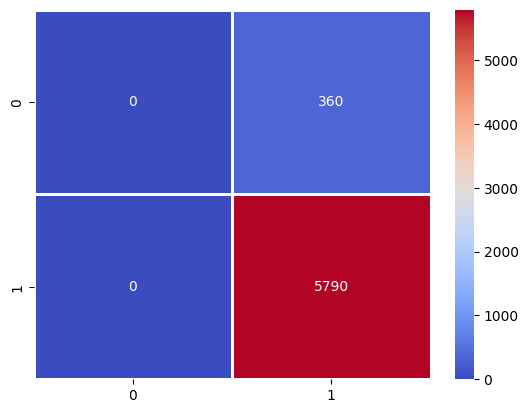

In [17]:
cfm_matrix = confusion_matrix(y_teste,previsoes_bayes)
sns.heatmap(cfm_matrix, cmap='coolwarm', annot=True, linewidth=1, fmt='d')
plt.show()

Variáveis mais relevantes:
Frequência_consumo_de_televisão: 0.073869751105136
Escolaridade: 0.06594209910592339
Consumo_de_sal: 0.05988331754098817
Frequência_distúrbios_do_sono: 0.05863404894793457
Frequência_sintomas_depressivos: 0.05500459158900641
Frequência_consumo_frutas: 0.0517389242733682
Frequência_falta_de_disposição: 0.05066175394610061
Frequência_consumo_carne_vermelha: 0.04846461904731877
Frequência_falta_de_interesse: 0.04659053650925012
Faixa_IMC: 0.04519204075013659
Cor/Raça: 0.04368535906585278
Diabetes: 0.04129931534243512
Tempo_parou_de_fumar: 0.03972967603440392
Início_tabagismo: 0.033203260065078705
Doença_mental: 0.03251596702917141
Consumo_de_álcool: 0.030186303889598518
Frequência_consumo_suco_caixinha: 0.028580550700175737
Jornada_de_Trabalho: 0.027843814443490322
Método_contraceptivo: 0.02690772947393063
Frequência_consumo_refrigerante: 0.025596076433878203
Sexo: 0.02462596094925208
Plano_de_saúde: 0.02436513339548932
Quantidade_de_trabalhos: 0.023430104646786

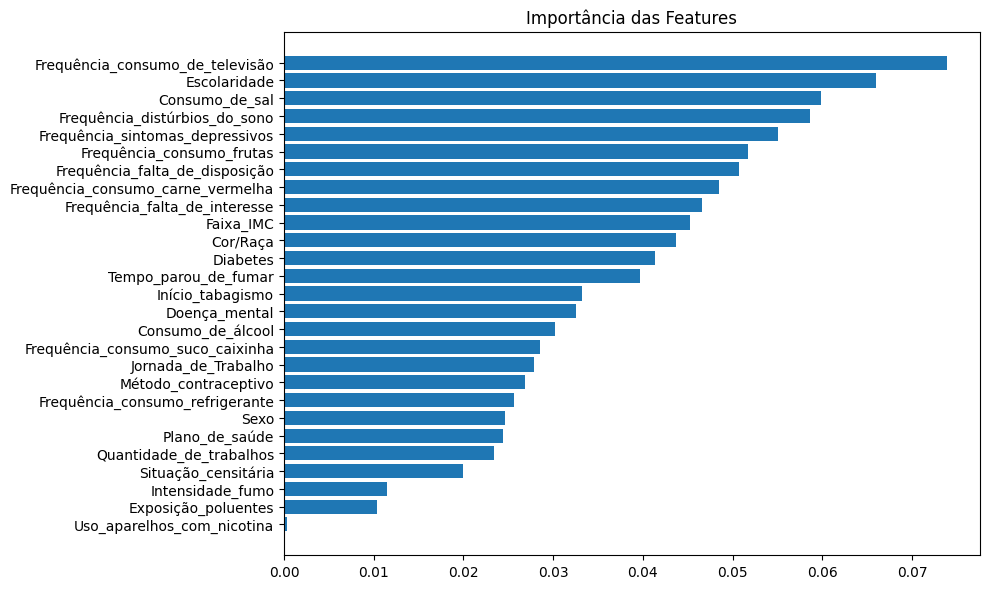

In [18]:
# Obter a importância das features
importancias = best_model_bayes.feature_importances_

# Pegando os nomes dos atributos
nomes_das_features = feature_names

# Ordenar as features com base na importância
indices_ordenados = np.argsort(importancias)[::-1]

# Exibir as features mais importantes
print("Variáveis mais relevantes:")
for idx in indices_ordenados:
    print(f"{nomes_das_features[idx]}: {importancias[idx]}")

# Plotar a importância das features
plt.figure(figsize=(10, 6))
plt.title("Importância das Features")
plt.barh(range(X_treino.shape[1]), importancias[indices_ordenados], align="center")
nomes_array = np.array(nomes_das_features)
plt.yticks(range(X_treino.shape[1]), nomes_array[indices_ordenados])
plt.gca().invert_yaxis()  # Inverter o eixo y para que as features mais importantes fiquem no topo
plt.tight_layout()
plt.show()

### OverSampling

In [ ]:
bayes_search.fit(X_treino_over, y_treino_over)
print("\nMelhores parâmetros encontrados com BayesSearchCV:")
print(bayes_search.best_params_)
print("Melhor pontuação de validação cruzada: {:.2f}".format(bayes_search.best_score_))

In [ ]:
best_model_bayes = bayes_search.best_estimator_

In [ ]:
previsoes_bayes = best_model_bayes.predict(X_teste_over)

In [ ]:
print(classification_report(y_teste_over, previsoes_bayes))

              precision    recall  f1-score   support

         1.0       0.18      0.02      0.03       360
         2.0       0.94      1.00      0.97      5790

    accuracy                           0.94      6150
   macro avg       0.56      0.51      0.50      6150
weighted avg       0.90      0.94      0.91      6150



Variáveis mais relevantes:
Consumo_de_sal: 0.08110412041127049
Frequência_consumo_de_televisão: 0.06990221499868116
Frequência_falta_de_interesse: 0.0677452078754072
Frequência_distúrbios_do_sono: 0.06404919488686388
Frequência_sintomas_depressivos: 0.061438918857695105
Sexo: 0.0585346000237866
Diabetes: 0.05547979079957161
Exercício_físico: 0.054752056712464386
Cor/Raça: 0.045181823316327425
Frequência_consumo_refrigerante: 0.035991848270089964
Frequência_consumo_frutas: 0.035606432335251986
Frequência_consumo_carne_vermelha: 0.03420378985531049
Plano_de_saúde: 0.034157747843272766
Doença_mental: 0.033896125746878496
Situação_censitária: 0.03300094221647528
Jornada_de_Trabalho: 0.03233530703274007
Faixa_IMC: 0.031572431855447336
Quantidade_de_trabalhos: 0.027522021214455912
Renda: 0.025861501447322875
Consumo_de_álcool: 0.025781987393259417
Tempo_parou_de_fumar: 0.024065999326737024
Frequência_consumo_suco_caixinha: 0.023639557956069923
Início_tabagismo: 0.020947215297556318
Exposição

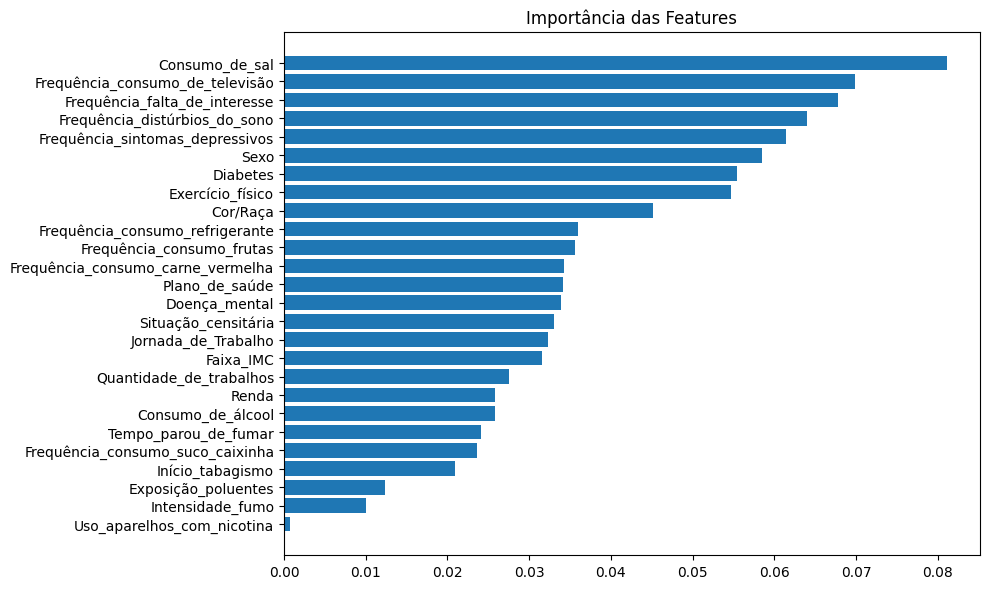

In [ ]:
# Obter a importância das features
importancias = best_model_bayes.feature_importances_

# Pegando os nomes dos atributos
nomes_das_features = feature_names

# Ordenar as features com base na importância
indices_ordenados = np.argsort(importancias)[::-1]

# Exibir as features mais importantes
print("Variáveis mais relevantes:")
for idx in indices_ordenados:
    print(f"{nomes_das_features[idx]}: {importancias[idx]}")

# Plotar a importância das features
plt.figure(figsize=(10, 6))
plt.title("Importância das Features")
plt.barh(range(X_treino.shape[1]), importancias[indices_ordenados], align="center")
nomes_array = np.array(nomes_das_features)
plt.yticks(range(X_treino.shape[1]), nomes_array[indices_ordenados])
plt.gca().invert_yaxis()  # Inverter o eixo y para que as features mais importantes fiquem no topo
plt.tight_layout()
plt.show()

### UnderSampling

In [ ]:
bayes_search.fit(X_treino_under, y_treino_under)
print("\nMelhores parâmetros encontrados com BayesSearchCV:")
print(bayes_search.best_params_)
print("Melhor pontuação de validação cruzada: {:.2f}".format(bayes_search.best_score_))


Melhores parâmetros encontrados com BayesSearchCV:
OrderedDict({'criterion': 'gini', 'max_depth': 31, 'max_features': 4, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 113})
Melhor pontuação de validação cruzada: 0.94


In [ ]:
best_model_bayes = bayes_search.best_estimator_

In [ ]:
previsoes_bayes = best_model_bayes.predict(X_teste_under)

In [ ]:
print(classification_report(y_teste_under, previsoes_bayes))

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       360
         2.0       0.94      1.00      0.97      5790

    accuracy                           0.94      6150
   macro avg       0.47      0.50      0.48      6150
weighted avg       0.89      0.94      0.91      6150



c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Variáveis mais relevantes:
Frequência_consumo_de_televisão: 0.08277413420735691
Frequência_distúrbios_do_sono: 0.06052291000188647
Consumo_de_sal: 0.06024677311041344
Frequência_consumo_frutas: 0.05921481555131692
Frequência_consumo_carne_vermelha: 0.05601734641151114
Faixa_IMC: 0.054199541817201234
Frequência_sintomas_depressivos: 0.05289698882728045
Frequência_falta_de_interesse: 0.05254159224186877
Cor/Raça: 0.049733647355165125
Renda: 0.04800088209617692
Tempo_parou_de_fumar: 0.041781718623725164
Início_tabagismo: 0.03975473149105515
Frequência_consumo_suco_caixinha: 0.03439456166037228
Consumo_de_álcool: 0.03425580778607584
Diabetes: 0.033018854789057264
Frequência_consumo_refrigerante: 0.030219411911927528
Doença_mental: 0.02958588861398861
Exercício_físico: 0.0291798877376429
Sexo: 0.02900261600642163
Plano_de_saúde: 0.025117966872269658
Jornada_de_Trabalho: 0.025004058222769576
Situação_censitária: 0.024431704436974257
Quantidade_de_trabalhos: 0.02068331722682417
Intensidade_fu

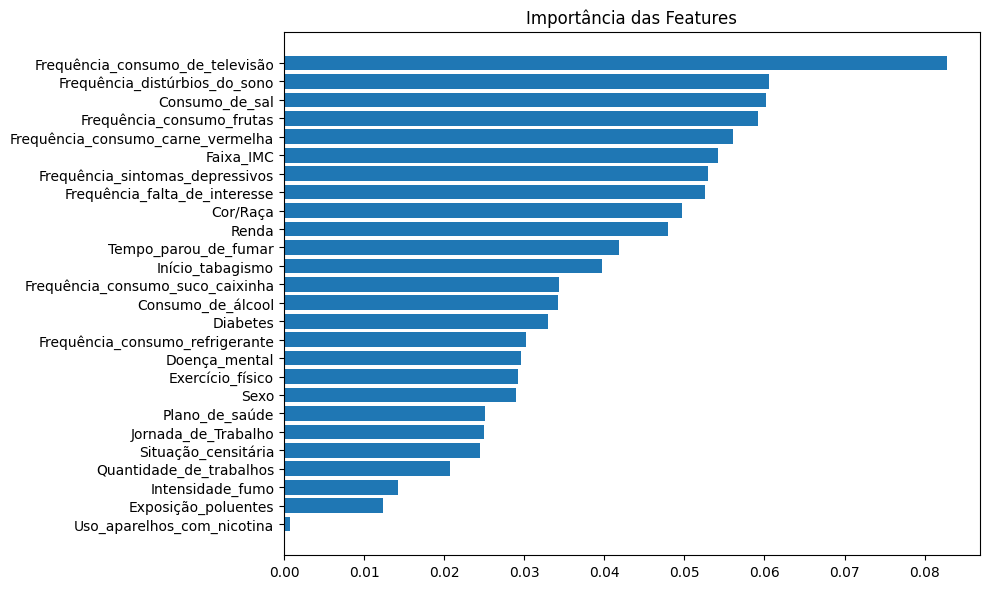

In [ ]:
# Obter a importância das features
importancias = best_model_bayes.feature_importances_

# Pegando os nomes dos atributos
nomes_das_features = feature_names

# Ordenar as features com base na importância
indices_ordenados = np.argsort(importancias)[::-1]

# Exibir as features mais importantes
print("Variáveis mais relevantes:")
for idx in indices_ordenados:
    print(f"{nomes_das_features[idx]}: {importancias[idx]}")

# Plotar a importância das features
plt.figure(figsize=(10, 6))
plt.title("Importância das Features")
plt.barh(range(X_treino.shape[1]), importancias[indices_ordenados], align="center")
nomes_array = np.array(nomes_das_features)
plt.yticks(range(X_treino.shape[1]), nomes_array[indices_ordenados])
plt.gca().invert_yaxis()  # Inverter o eixo y para que as features mais importantes fiquem no topo
plt.tight_layout()
plt.show()

### Random UnderSampling

In [ ]:
bayes_search.fit(X_treino_rd_under, y_treino_rd_under)
print("\nMelhores parâmetros encontrados com BayesSearchCV:")
print(bayes_search.best_params_)
print("Melhor pontuação de validação cruzada: {:.2f}".format(bayes_search.best_score_))


Melhores parâmetros encontrados com BayesSearchCV:
OrderedDict({'criterion': 'entropy', 'max_depth': 43, 'max_features': 2, 'min_samples_leaf': 10, 'min_samples_split': 9, 'n_estimators': 53})
Melhor pontuação de validação cruzada: 0.67


In [ ]:
best_model_bayes = bayes_search.best_estimator_

In [ ]:
previsoes_bayes = best_model_bayes.predict(X_teste_rd_under)

In [ ]:
print(classification_report(y_teste_rd_under, previsoes_bayes))

              precision    recall  f1-score   support

         1.0       0.10      0.60      0.17       360
         2.0       0.96      0.66      0.79      5790

    accuracy                           0.66      6150
   macro avg       0.53      0.63      0.48      6150
weighted avg       0.91      0.66      0.75      6150



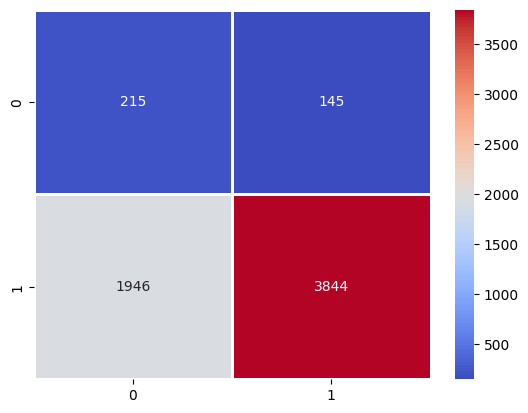

In [ ]:
cfm_matrix = confusion_matrix(y_teste,previsoes_bayes)
sns.heatmap(cfm_matrix, cmap='coolwarm', annot=True, linewidth=1, fmt='d')
plt.show()

Variáveis mais relevantes:
Frequência_distúrbios_do_sono: 0.09796423242594765
Frequência_falta_de_interesse: 0.07680914685342102
Frequência_sintomas_depressivos: 0.0710032704264866
Doença_mental: 0.0709005941951661
Jornada_de_Trabalho: 0.06297564793774905
Consumo_de_sal: 0.05658012746226124
Tempo_parou_de_fumar: 0.055384908575752616
Diabetes: 0.052776876587409254
Frequência_consumo_de_televisão: 0.04592329445302357
Quantidade_de_trabalhos: 0.03839173480418449
Frequência_consumo_carne_vermelha: 0.03814676011016132
Início_tabagismo: 0.03449807239761764
Frequência_consumo_frutas: 0.034448341976110027
Renda: 0.03402058660474073
Frequência_consumo_refrigerante: 0.030895621614398346
Cor/Raça: 0.026855543764845998
Faixa_IMC: 0.026662867991852916
Consumo_de_álcool: 0.024767984022559045
Frequência_consumo_suco_caixinha: 0.02364701734759938
Situação_censitária: 0.022138036029205634
Sexo: 0.01923081034693074
Intensidade_fumo: 0.017828015522714763
Plano_de_saúde: 0.014316209416031081
Exercício_fís

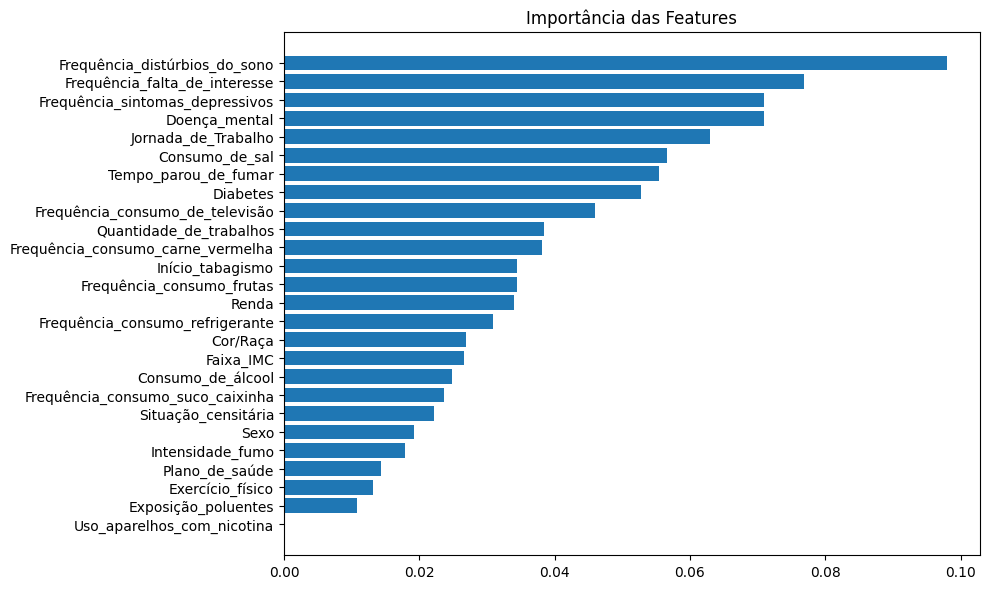

In [ ]:
# Obter a importância das features
importancias = best_model_bayes.feature_importances_

# Pegando os nomes dos atributos
nomes_das_features = feature_names

# Ordenar as features com base na importância
indices_ordenados = np.argsort(importancias)[::-1]

# Exibir as features mais importantes
print("Variáveis mais relevantes:")
for idx in indices_ordenados:
    print(f"{nomes_das_features[idx]}: {importancias[idx]}")

# Plotar a importância das features
plt.figure(figsize=(10, 6))
plt.title("Importância das Features")
plt.barh(range(X_treino.shape[1]), importancias[indices_ordenados], align="center")
nomes_array = np.array(nomes_das_features)
plt.yticks(range(X_treino.shape[1]), nomes_array[indices_ordenados])
plt.gca().invert_yaxis()  # Inverter o eixo y para que as features mais importantes fiquem no topo
plt.tight_layout()
plt.show()

### DSTO

In [ ]:
bayes_search.fit(X_treino_DSTO, y_treino_DSTO)
print("\nMelhores parâmetros encontrados com BayesSearchCV:")
print(bayes_search.best_params_)
print("Melhor pontuação de validação cruzada: {:.2f}".format(bayes_search.best_score_))


Melhores parâmetros encontrados com BayesSearchCV:
OrderedDict({'criterion': 'gini', 'max_depth': 37, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 14, 'n_estimators': 79})
Melhor pontuação de validação cruzada: 0.97


In [ ]:
best_model_bayes = bayes_search.best_estimator_

In [ ]:
previsoes_bayes = best_model_bayes.predict(X_teste_DSTO)

In [ ]:
print(classification_report(y_teste_DSTO, previsoes_bayes))

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       360
         2.0       0.94      1.00      0.97      5790

    accuracy                           0.94      6150
   macro avg       0.47      0.50      0.48      6150
weighted avg       0.89      0.94      0.91      6150



c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bkser\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Variáveis mais relevantes:
Intensidade_fumo: 0.23852176724167642
Plano_de_saúde: 0.13438575577458511
Frequência_falta_de_interesse: 0.11010917053189276
Doença_mental: 0.0755683125693064
Frequência_sintomas_depressivos: 0.07541241175862856
Consumo_de_sal: 0.04815478457293521
Uso_aparelhos_com_nicotina: 0.04350734661067628
Diabetes: 0.0432904064509052
Tempo_parou_de_fumar: 0.036479063777272266
Sexo: 0.029537312175193772
Cor/Raça: 0.026693440746176265
Renda: 0.02413045476409641
Exposição_poluentes: 0.016869832258124568
Situação_censitária: 0.01454626986323353
Frequência_consumo_suco_caixinha: 0.012876367591492828
Frequência_consumo_frutas: 0.012588299456774359
Quantidade_de_trabalhos: 0.010759010759004447
Frequência_distúrbios_do_sono: 0.0093098461310268
Frequência_consumo_refrigerante: 0.007014260403368337
Consumo_de_álcool: 0.006430500002980567
Jornada_de_Trabalho: 0.0052561460381325975
Início_tabagismo: 0.00439576489975634
Faixa_IMC: 0.004143606215481966
Exercício_físico: 0.00392043547

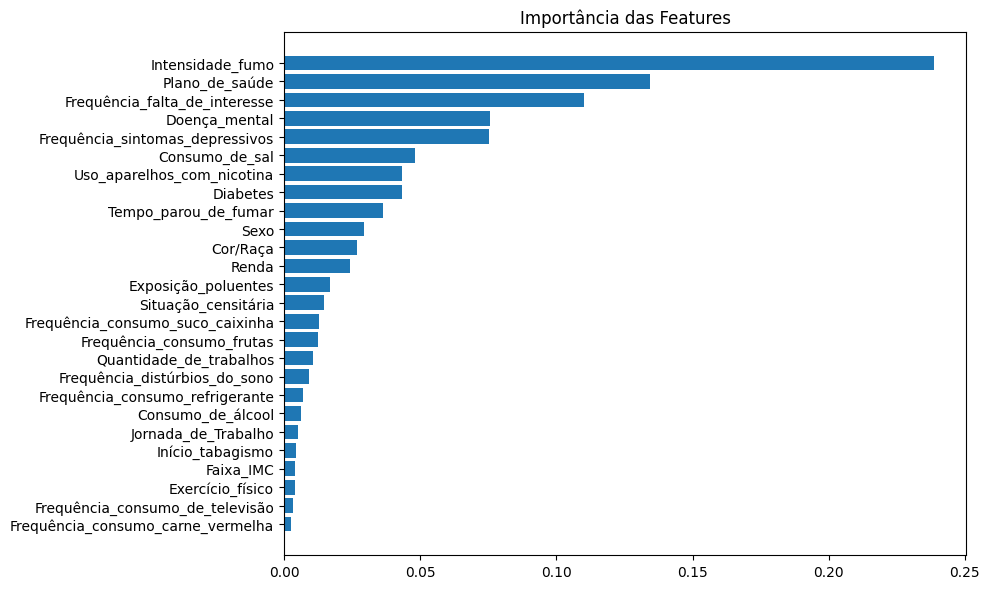

In [ ]:
# Obter a importância das features
importancias = best_model_bayes.feature_importances_

# Pegando os nomes dos atributos
nomes_das_features = feature_names

# Ordenar as features com base na importância
indices_ordenados = np.argsort(importancias)[::-1]

# Exibir as features mais importantes
print("Variáveis mais relevantes:")
for idx in indices_ordenados:
    print(f"{nomes_das_features[idx]}: {importancias[idx]}")

# Plotar a importância das features
plt.figure(figsize=(10, 6))
plt.title("Importância das Features")
plt.barh(range(X_treino.shape[1]), importancias[indices_ordenados], align="center")
nomes_array = np.array(nomes_das_features)
plt.yticks(range(X_treino.shape[1]), nomes_array[indices_ordenados])
plt.gca().invert_yaxis()  # Inverter o eixo y para que as features mais importantes fiquem no topo
plt.tight_layout()
plt.show()